In [2]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("MovieDataThread.csv")

In [4]:
df = df[df["imdb_id"].notna()]
df.drop(columns="imdb_id", inplace=True)
df.drop(columns=[col for col in df.columns if col.startswith('tmdb_')], inplace=True)

In [5]:
df["genre_count"] = df.filter(regex='^imdb_(?!id$)').count(axis=1)

In [10]:
len(df["genre_count"] >= 1)

37341

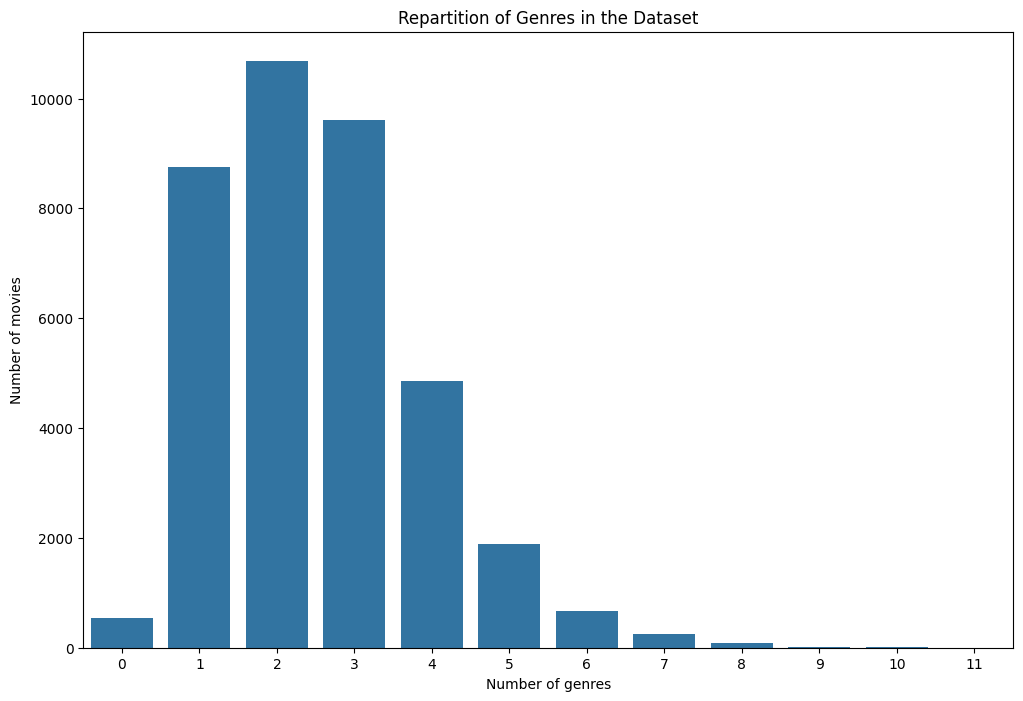

In [17]:
plt.figure(figsize=(12, 8))
sns.countplot(x="genre_count", data=df)
plt.xlabel('Number of genres')
plt.ylabel('Number of movies')
plt.title('Repartition of Genres in the Dataset')
plt.show()

In [6]:
comedy = df[df["imdb_comedy"].notna()]
gay_comedy = comedy[comedy["gay_count"] > 0]

KeyError: 'gay_count'

# TMDB Analysis

In [6]:
len(df[df["synopsis"].notna()].synopsis)

11351

In [7]:
df["genre_count_imdb"] = df.filter(regex='^imdb_(?!id$)').count(axis=1)
df["genre_count_tmdb"] = df.filter(regex='^tmdb_(?!id$)').count(axis=1)

In [8]:
one_genre = df[(df["genre_count_imdb"] == 1) & (df["genre_count_tmdb"] == 1)]
one_genre["genre_imdb"] = one_genre.filter(regex='^imdb_').idxmin(axis=1)
one_genre["genre_tmdb"] = one_genre.filter(regex='^tmdb_').idxmin(axis=1)

In [9]:
one_genre["genre_imdb"] = one_genre["genre_imdb"].str.replace("imdb_", "")
one_genre["genre_tmdb"] = one_genre["genre_tmdb"].str.replace("tmdb_", "")

In [10]:
same_genre = one_genre[one_genre["genre_imdb"] == one_genre["genre_tmdb"]]

In [11]:
len(same_genre)

0

In [12]:
# diff = df[((df["genre_count_imdb"] == 1) & (df["genre_count_tmdb"] != 1)) | (df["genre_count_imdb"] != 1) & (df["genre_count_tmdb"] == 1)]
diff = df[((df["genre_count_imdb"] == 1) & (df["genre_count_tmdb"] > 1))]
len(diff)

0

In [13]:
diff = df[((df["genre_count_imdb"] == 1) & (df["genre_count_tmdb"] == 1))]

In [14]:
len(diff)

0

# Decades analysis

In [8]:
def split_t(title) :
    match = re.search(r'\((\d{4})\)', title)
    if match:
        year = match.group(1)
        title_before_year = title.replace(f"({year})", "").strip()
        return title_before_year, year
    else:
        return None

In [9]:
df["year"] = df["Title"].apply(lambda x: split_t(x)[1] if split_t(x) else None)
df["decade"] = df["year"].apply(lambda x: str(x)[:3] + "0" if x else None)

## One genre

### All genres

In [10]:
df["genre_count"] = df.filter(regex='^imdb_(?!id$)').count(axis=1)
one_genre = df[df["genre_count"] == 1]
one_genre["genre"] = one_genre.filter(regex='^imdb_').idxmin(axis=1)
one_genre_count = one_genre["genre"].value_counts()
# Split genre_count into quartiles
genre_counts_quartiles = one_genre_count.quantile([0.25, 0.5, 0.75])
# Select genres that are in the top quartile
top_genres = one_genre_count[one_genre_count >= genre_counts_quartiles[0.75]].index
filtered_movies = one_genre[one_genre[top_genres].notna().sum(axis=1) == 1]

/var/folders/wj/yjxhfpzn5ssgymw3vblf52fh0000gn/T/ipykernel_63770/3183589743.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  one_genre["genre"] = one_genre.filter(regex='^imdb_').idxmin(axis=1)


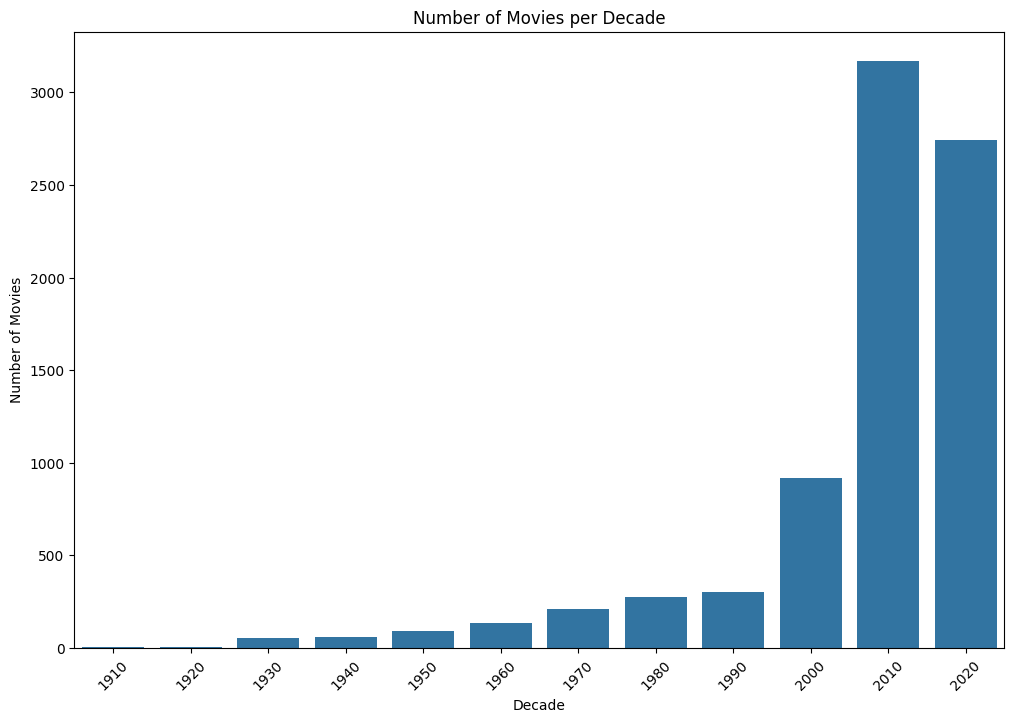

In [24]:
# Sort the decades
sorted_decades = sorted(filtered_movies["decade"].dropna().unique())

# Plot number of movies per decade
plt.figure(figsize=(12, 8))
sns.countplot(x="decade", data=filtered_movies, order=sorted_decades)
plt.xlabel('Decade')
plt.ylabel('Number of Movies')
plt.title('Number of Movies per Decade')
plt.xticks(rotation=45)
plt.show()

In [11]:
genre_columns = [col for col in one_genre.columns if col.startswith('imdb_') or col.startswith('tmdb_')]
genre_by_decade = one_genre.groupby('decade')[genre_columns].sum()
genre_by_decade.reset_index(inplace=True)
genre_by_decade.set_index('decade', inplace=True)
genre_by_decade.loc['Total'] = genre_by_decade.sum()
genre_by_decade

,imdb_action,imdb_adventure,imdb_animation,imdb_biography,imdb_comedy,imdb_crime,imdb_documentary,imdb_drama,imdb_family,imdb_fantasy,...,imdb_reality-tv,imdb_romance,imdb_sci-fi,imdb_short,imdb_sport,imdb_talk-show,imdb_thriller,imdb_war,imdb_western,imdb_adult
decade,,,,,,,,,,,,,,,,,,,,,
1910,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1920,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1930,0.0,1.0,0.0,0.0,15.0,0.0,0.0,38.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,3.0,0.0
1940,0.0,0.0,0.0,0.0,25.0,0.0,1.0,33.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,15.0,0.0
1950,0.0,1.0,0.0,0.0,22.0,0.0,1.0,66.0,2.0,0.0,...,0.0,0.0,4.0,1.0,0.0,4.0,0.0,0.0,37.0,0.0
1960,0.0,4.0,0.0,0.0,33.0,0.0,3.0,78.0,0.0,0.0,...,0.0,1.0,3.0,0.0,0.0,1.0,3.0,0.0,19.0,0.0
1970,3.0,0.0,1.0,1.0,54.0,1.0,10.0,96.0,1.0,1.0,...,0.0,0.0,3.0,1.0,0.0,2.0,6.0,0.0,4.0,0.0
1980,5.0,2.0,0.0,1.0,88.0,0.0,26.0,90.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,2.0,7.0,0.0,0.0,0.0
1990,10.0,3.0,1.0,0.0,78.0,1.0,36.0,141.0,1.0,0.0,...,1.0,0.0,2.0,4.0,0.0,4.0,6.0,0.0,2.0,0.0


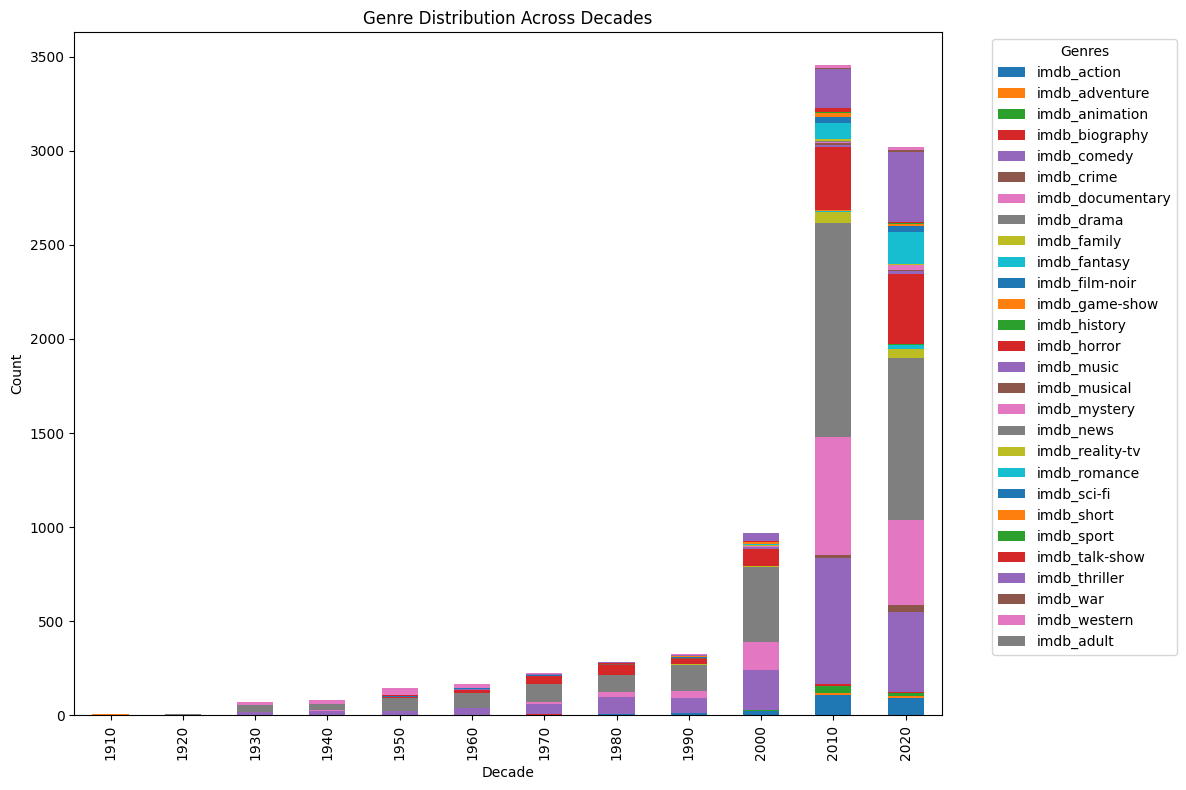

In [27]:
import matplotlib.pyplot as plt

# Plot the genre distribution across decades
genre_by_decade.drop('Total', inplace=False).plot(kind='bar', stacked=True, figsize=(12, 8))

plt.title('Genre Distribution Across Decades')
plt.xlabel('Decade')
plt.ylabel('Count')
plt.legend(title='Genres', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [32]:
# Calculate the size of the script for each row
one_genre['script_size'] = one_genre['Script'].apply(lambda x: len(x) if isinstance(x, str) else 0)

# Group by decade and genre, summing the script sizes
script_size_by_decade_genre = one_genre.groupby(['decade'])[genre_columns].apply(
    lambda group: group.mul(one_genre.loc[group.index, 'script_size'], axis=0).mean()
)

# Reset the index to make decades the index
script_size_by_decade_genre.reset_index(inplace=True)
script_size_by_decade_genre.set_index('decade', inplace=True)

script_size_by_decade_genre

/var/folders/wj/yjxhfpzn5ssgymw3vblf52fh0000gn/T/ipykernel_16895/3223285569.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  one_genre['script_size'] = one_genre['Script'].apply(lambda x: len(x) if isinstance(x, str) else 0)


,imdb_action,imdb_adventure,imdb_animation,imdb_biography,imdb_comedy,imdb_crime,imdb_documentary,imdb_drama,imdb_family,imdb_fantasy,...,imdb_reality-tv,imdb_romance,imdb_sci-fi,imdb_short,imdb_sport,imdb_talk-show,imdb_thriller,imdb_war,imdb_western,imdb_adult
decade,,,,,,,,,,,,,,,,,,,,,
1910,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6090.000000,NaN,NaN,...,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN,NaN,NaN
1920,NaN,NaN,NaN,NaN,NaN,NaN,5241.000000,6538.200000,NaN,NaN,...,NaN,NaN,NaN,5649.000000,NaN,6327.000000,NaN,NaN,NaN,NaN
1930,NaN,40225.000000,NaN,NaN,45365.000000,NaN,NaN,39551.789474,NaN,3210.000000,...,NaN,NaN,NaN,NaN,NaN,43924.500000,NaN,NaN,46671.000000,NaN
1940,NaN,NaN,NaN,NaN,54628.320000,NaN,49099.000000,48274.181818,NaN,NaN,...,NaN,NaN,NaN,7085.000000,NaN,61208.000000,NaN,70996.000000,44923.733333,NaN
1950,NaN,34013.000000,NaN,NaN,48921.227273,NaN,43251.000000,47045.075758,47868.000000,NaN,...,NaN,NaN,48631.250000,3471.000000,NaN,46348.250000,NaN,NaN,38404.513514,NaN
1960,NaN,52381.000000,NaN,NaN,47994.242424,NaN,45353.666667,41351.794872,NaN,NaN,...,NaN,56231.000000,26876.000000,NaN,NaN,26914.000000,34641.333333,NaN,35143.684211,NaN
1970,26139.333333,NaN,5569.000000,47553.000000,42752.555556,34278.000000,44645.300000,39170.677083,39343.000000,26265.000000,...,NaN,NaN,27117.666667,3342.000000,NaN,47023.500000,25977.000000,NaN,27431.250000,NaN
1980,39964.600000,13702.000000,NaN,28961.000000,45143.386364,NaN,35257.807692,39459.455556,NaN,NaN,...,NaN,NaN,39445.000000,3879.000000,NaN,27730.000000,31255.714286,NaN,NaN,NaN
1990,40048.700000,36128.666667,13307.000000,NaN,48355.384615,7831.000000,34860.583333,42911.702128,36333.000000,NaN,...,39797.000000,NaN,61678.500000,24938.500000,NaN,39022.500000,34925.833333,NaN,33119.500000,NaN


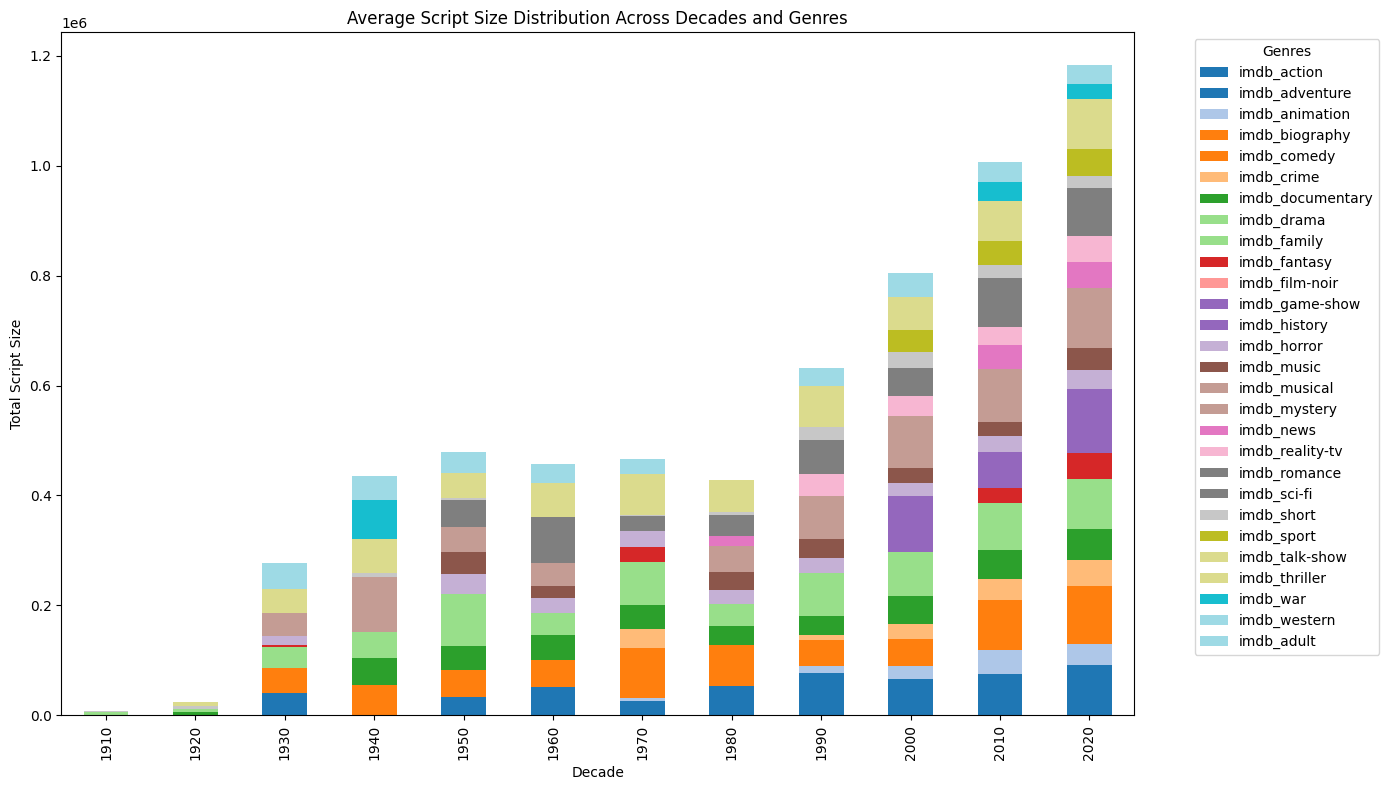

In [34]:
import matplotlib.pyplot as plt

# Plot the script size distribution across decades and genres
script_size_by_decade_genre.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='tab20')

plt.title('Average Script Size Distribution Across Decades and Genres')
plt.xlabel('Decade')
plt.ylabel('Total Script Size')
plt.legend(title='Genres', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### First quartile

In [36]:
filtered_movies.genre.unique()

array(['imdb_horror', 'imdb_drama', 'imdb_comedy', 'imdb_action',
       'imdb_thriller', 'imdb_documentary', 'imdb_romance'], dtype=object)

### Analyse avant après 2000

# Analyse de la représentations homosexuel à travers les années

Attardons nous sur le mot "gay"

## Par decennie

### Analyse statistique

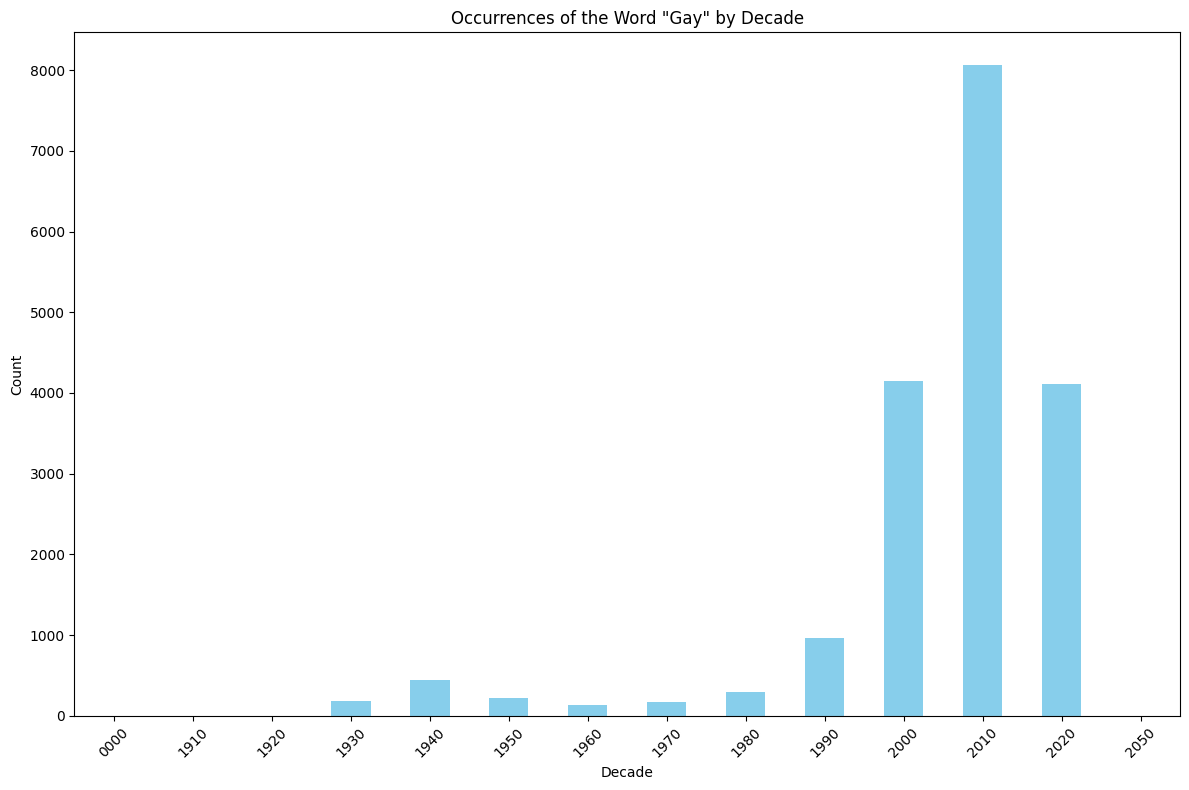

In [12]:
# Count the occurrences of the word "gay" in the "Script" column
df["gay_count"] = df["Script"].apply(lambda x: x.lower().count("gay") if isinstance(x, str) else 0)

# Group by decade and sum the counts
gay_count_by_decade = df.groupby("decade")["gay_count"].sum()

import matplotlib.pyplot as plt

# Plot the gay count by decade
gay_count_by_decade.plot(kind='bar', figsize=(12, 8), color='skyblue')

plt.title('Occurrences of the Word "Gay" by Decade')
plt.xlabel('Decade')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

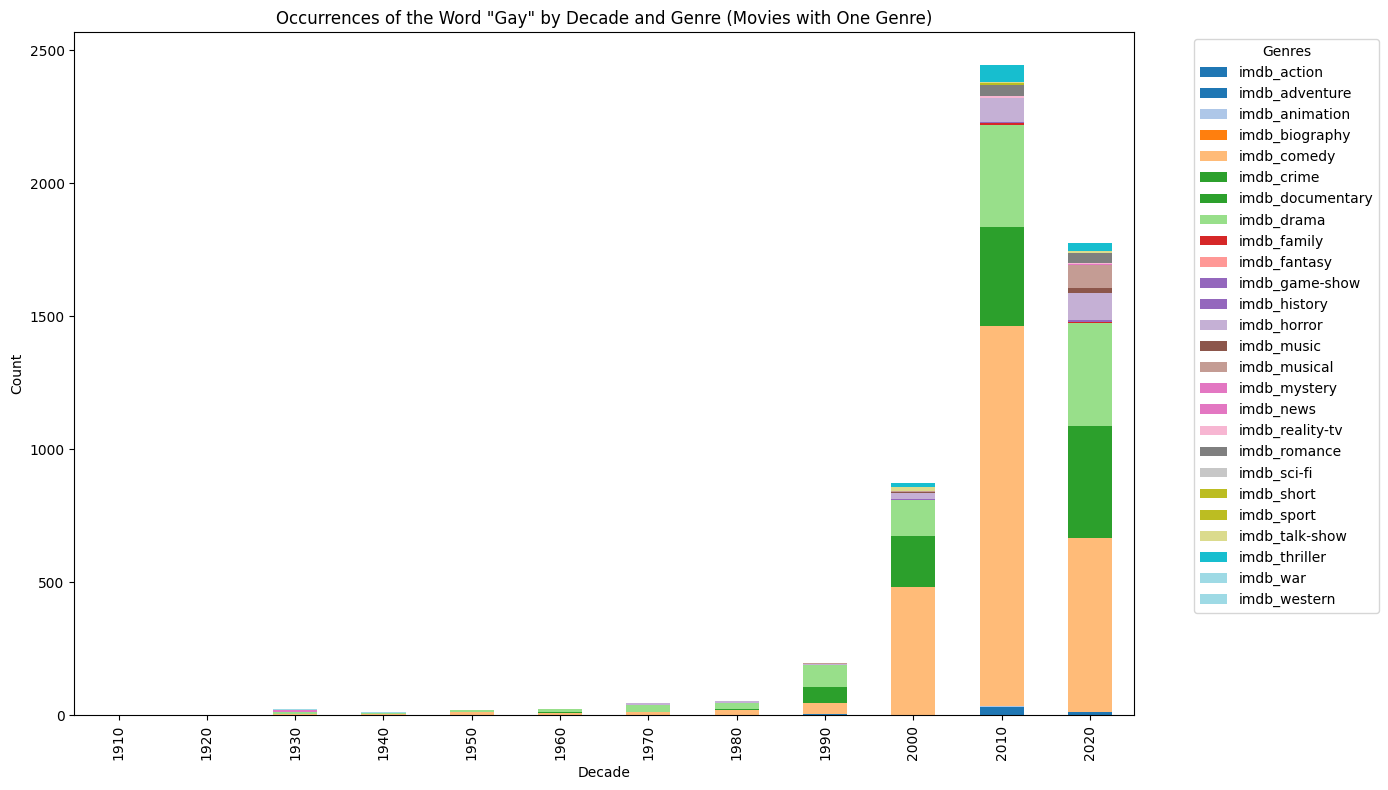

In [13]:
# Count the occurrences of the word "gay" in the "Script" column per decade and per genre
gay_count_by_decade_genre = one_genre.groupby(['decade', 'genre'])['Script'].apply(
    lambda scripts: scripts.str.lower().str.count('gay').sum()
).unstack()

# Display the result
import matplotlib.pyplot as plt

# Plot the occurrences of the word "gay" by decade and genre
gay_count_by_decade_genre.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='tab20')

plt.title('Occurrences of the Word "Gay" by Decade and Genre (Movies with One Genre)')
plt.xlabel('Decade')
plt.ylabel('Count')
plt.legend(title='Genres', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [53]:
# One genre
top_genres_with_gay = gay_count_by_decade_genre.sum().sort_values(ascending=False).head(3)
print(top_genres_with_gay)

genre
imdb_comedy         2668.0
imdb_drama          1070.0
imdb_documentary    1044.0
dtype: float64


### Focus sur les comédies (tous les films avec comedy en genre)

In [17]:
comedy = df[df["imdb_comedy"].notna()]

In [98]:
# Les comedies qui contiennent le mots gay dans leur script
gay_comedy = comedy[comedy["gay_count"] > 0]

In [ ]:
# Calculate the total count of scripts per decade
scripts_per_decade = comedy.groupby("decade")["Script"].count()

# Calculate the number of "gay" occurrences per decade in comedy
gay_count_by_decade_comedy = comedy.groupby("decade")["gay_count"].sum()

# Calculate the proportion of "gay" occurrences per script by decade
proportion_gay_per_script = (gay_count_by_decade_comedy / scripts_per_decade)

# Display the result
print(proportion_gay_per_script)

decade
0000      0.000000
1910     20.000000
1920      0.000000
1930     43.534483
1940     78.189300
1950     37.378641
1960     22.605364
1970     24.148607
1980     23.519737
1990     63.204420
2000    147.910136
2010    114.629405
2020     81.412165
2050      0.000000
dtype: float64


In [99]:
gay_comedy.loc[:, gay_comedy.filter(regex='^imdb_').columns] = gay_comedy.filter(regex='^imdb_').notna().astype(float)

In [101]:
gay_comedy_associated_genre = gay_comedy.drop(columns=["imdb_comedy"])

In [108]:
# Calculate the sum of genre columns
genre_sum = gay_comedy_associated_genre.filter(regex='^imdb_').sum().sort_values(ascending=False).head(10)

# Print the result
print(genre_sum)

imdb_drama          924.0
imdb_romance        853.0
imdb_crime          189.0
imdb_action         179.0
imdb_horror         174.0
imdb_thriller       152.0
imdb_fantasy        150.0
imdb_musical        137.0
imdb_adventure      135.0
imdb_documentary     97.0
dtype: float64


In [116]:
# Find the genre with the maximum occurrence per decade
top_genre_per_decade = gay_comedy_associated_genre.set_index("decade", drop=True).filter(like="imdb_").groupby('decade').sum().idxmax(axis=1)

# Print the result
print(top_genre_per_decade)

decade
1910    imdb_adventure
1930      imdb_romance
1940      imdb_romance
1950      imdb_romance
1960      imdb_romance
1970        imdb_drama
1980        imdb_drama
1990        imdb_drama
2000      imdb_romance
2010        imdb_drama
2020        imdb_drama
dtype: object


#### Word2Vec

In [120]:
# tokens
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

X = gay_comedy["Script"].apply(lambda x: word_tokenize(x.lower()) if isinstance(x, str) else [])

In [129]:
# Word2Vec
from gensim.models import Word2Vec  
from nltk.tokenize import word_tokenize

# Exemple pour une décennie  
def train_decade_embedding(scripts_decade, vector_size=100, window=5):  
    tokens = [word_tokenize(script.lower()) for script in scripts_decade if isinstance(script, str)]
    model = Word2Vec(tokens, vector_size=vector_size, window=window, min_count=10)  
    return model  

# Stocker les modèles par période  
embeddings = {decade: train_decade_embedding(scripts) for decade, scripts in gay_comedy.groupby('decade')['Script']}  

In [159]:
saved_models = {}
for decade, model in embeddings.items():
    model.save(f"word2vec_{decade}_comedy.model")
    saved_models[decade] = model

In [145]:
embeddings["2000"]

In [141]:
for decade, model in embeddings.items():  
    print(f"Top 10 mots proches de 'gay' dans les {decade}s:")  
    if "gay" in model.wv.key_to_index:  
        print(model.wv.most_similar("gay", topn=10))  

Top 10 mots proches de 'gay' dans les 1910s:
Top 10 mots proches de 'gay' dans les 1930s:
[('friendly', 0.8748636841773987), ('gallant', 0.8643858432769775), ('sweethearts', 0.8624078631401062), ('bright', 0.8619088530540466), ('merry', 0.8596914410591125), ('noble', 0.8593750596046448), ('twice', 0.8532761335372925), ('pride', 0.8507579565048218), ('strong', 0.8498528599739075), ('add', 0.8495069146156311)]
Top 10 mots proches de 'gay' dans les 1940s:
[('strong', 0.7614737153053284), ('also', 0.7379245162010193), ('soft', 0.734226644039154), ('bright', 0.7294805645942688), ('typical', 0.7274690866470337), ('taste', 0.7233999967575073), ('star', 0.7218376398086548), ('suddenly', 0.7208184599876404), ('amusing', 0.7159795761108398), ('famous', 0.7157794833183289)]
Top 10 mots proches de 'gay' dans les 1950s:
[('bright', 0.933891773223877), ('fresh', 0.9331348538398743), ('glorious', 0.9319214224815369), ('natural', 0.9255613088607788), ('army', 0.9210011959075928), ('nurse', 0.918883383

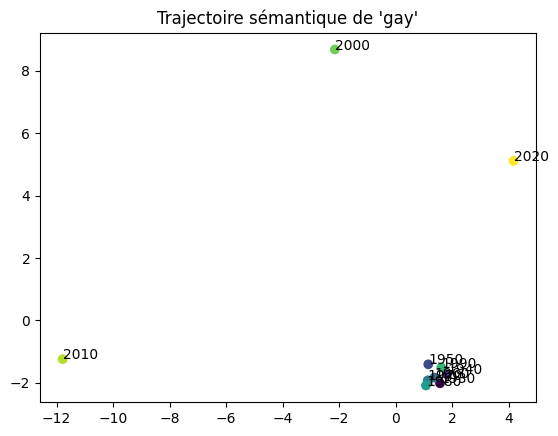

In [148]:
from sklearn.decomposition import PCA  
import matplotlib.pyplot as plt  

# Extraire les vecteurs de "gay" par décennie  
gay_vectors = [model.wv["gay"] for model in embeddings.values() if "gay" in model.wv]  
decades = [decade for decade, model in embeddings.items() if "gay" in model.wv]  

# Réduction de dimension  
pca = PCA(n_components=2)  
gay_pca = pca.fit_transform(gay_vectors)  

# Visualisation  
plt.scatter(gay_pca[:, 0], gay_pca[:, 1], c=range(len(decades)), cmap="viridis")  
for i, decade in enumerate(decades):  
    plt.annotate(decade, (gay_pca[i, 0], gay_pca[i, 1]))  
plt.title("Trajectoire sémantique de 'gay'")  
plt.show()  

vitesse de changement sémantique

In [158]:
import numpy as np

def semantic_speed(word, embeddings):
    speeds = []
    decades = sorted(embeddings.keys())  # Trier les décennies chronologiquement
    for i in range(1, len(decades)):
        prev_decade = decades[i-1]
        curr_decade = decades[i]
        
        # Vérifier si le mot existe dans les deux périodes
        if word in embeddings[prev_decade].wv and word in embeddings[curr_decade].wv:
            # Extraire les vecteurs
            prev_vector = embeddings[prev_decade].wv[word]
            curr_vector = embeddings[curr_decade].wv[word]
            
            # Calculer la distance (norme L2)
            distance = np.linalg.norm(curr_vector - prev_vector)
            speeds.append((f"{prev_decade}-{curr_decade}", distance))
    
    return speeds

# Exemple d'utilisation
speeds_gay = semantic_speed("gay", embeddings)
print("Vitesse de changement sémantique pour 'gay':")
for speed in speeds_gay:
    print(f"De {speed[0]}: {speed[1]:.4f}")

Vitesse de changement sémantique pour 'gay':
De 1930-1940: 3.3884
De 1940-1950: 3.5509
De 1950-1960: 2.2582
De 1960-1970: 1.9199
De 1970-1980: 2.2773
De 1980-1990: 6.8841
De 1990-2000: 12.4938
De 2000-2010: 15.8321
De 2010-2020: 17.7530


- Dans les années 30 - 60: \
Le terme "gay" conserve son sens étymologique (vieil anglais gai = "joyeux").
- Dans les années 70-80 : \
Le terme commence à être utilisé pour désigner l'homosexualité, mais il est encore largement associé à la joie et à la gaieté. ('romantic', 'happiest')
- Dans les années 90 : \
Termes négatifs upset, confused, dead, angry, drunk
- Dans les années 2000 : \
Période où "gay" est utilisé comme insulte dans les films, il est souvent utilisé dans des contextes similaires que "retarded, racist, f*g, dumb, selfish"
- A partir de 2010 : 
Termes techniques (bisexual, homosexual), Vocabulaire militant (homophobic, queer)

Il serait intéressant de faire une analyse de faire une analyse détaillée des films et du contexte historique de chaque décennie. \
Explication de drunk/sad : cliché de l'homosexuel qui boit pour oublier sa souffrance dû à son orientation sexuelle. \
Explication de "dead" : trope narratif récurrent dans les films de la communauté LGBTQ+ où le personnage principal meurt juste après qu'ils aient trouvé le bonheur, officialisé leur relation, ou juste avant un moment important dans leur acceptation de leur identité queer.

### Tous les genres

In [164]:
# Exemple pour une décennie  
def train_decade_embedding(scripts_decade, vector_size=100, window=5):  
    tokens = [word_tokenize(script.lower()) for script in scripts_decade if isinstance(script, str)]
    model = Word2Vec(tokens, vector_size=vector_size, window=window, min_count=10)  
    return model  

# Stocker les modèles par période  
embeddings = {decade: train_decade_embedding(scripts) for decade, scripts in df.groupby('decade')['Script']}  

In [165]:
# save
saved_models = {}
for decade, model in embeddings.items():
    model.save(f"word2vec_{decade}.model")
    saved_models[decade] = model

In [175]:
for decade, model in embeddings.items():  
    print(f"Top 10 mots proches de 'gay' dans les {decade}s:")  
    if "gay" in model.wv.key_to_index:  
        print(model.wv.most_similar("gay", topn=10))

Top 10 mots proches de 'gay' dans les 0000s:
Top 10 mots proches de 'gay' dans les 1910s:
Top 10 mots proches de 'gay' dans les 1920s:
Top 10 mots proches de 'gay' dans les 1930s:
[('cheerful', 0.7397658824920654), ('charming', 0.7134780883789062), ('sad', 0.709876298904419), ('brave', 0.6942809224128723), ('dull', 0.6886504292488098), ('pleasant', 0.6781171560287476), ('tender', 0.6744440793991089), ('gentle', 0.6740454435348511), ('romantic', 0.671806812286377), ('popular', 0.6633186936378479)]
Top 10 mots proches de 'gay' dans les 1940s:
[('sad', 0.7625999450683594), ('bright', 0.7359166145324707), ('gentle', 0.7269062399864197), ('romantic', 0.7187525629997253), ('tender', 0.6819809079170227), ('mild', 0.6806049942970276), ('divine', 0.6760739684104919), ('sweet', 0.6717274785041809), ('healthy', 0.6700677871704102), ('peaceful', 0.6675463914871216)]
Top 10 mots proches de 'gay' dans les 1950s:
[('bright', 0.6977594494819641), ('talented', 0.6717273592948914), ('carefree', 0.664788